# Stratégies — Trend following & signal SMA + VIX

Notebook de travail regroupant trois stratégies existantes et un **nouveau signal de trend
following filtré par le VIX**.

Principe transversal important : **le signal de tendance se calcule toujours sur l'indice
sous-jacent, jamais directement sur le prix de l'ETF à effet de levier.**
Pour **QLD (2×)** et **TQQQ (3×)**, le sous-jacent est le **Nasdaq-100 (`^NDX`)**. Le reset
quotidien du levier rend le prix de l'ETF bruité et path-dependent : on décide « dedans / dehors »
sur l'indice propre, puis on applique la position aux rendements de l'ETF.

Stratégies couvertes :
1. **TQQQ trend following** (SMA sur ^NDX)
2. **QLD trend following** (SMA sur ^NDX)
3. **Top-1** (plus grande capitalisation du S&P 500, basket équipondéré)
4. **Nouveau signal SMA + VIX** : binaire *et* continu (incréments de 0,1) pour le *sizing*.

> Rendement passé ≠ rendement futur. Cash hors marché = 0 %. Signaux décalés d'1 jour (pas de look-ahead).

## 1. Imports & configuration

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

START = "1990-01-01"
INDEX = "^NDX"      # Nasdaq-100 : sous-jacent de QLD & TQQQ
VIX   = "^VIX"      # indice de volatilité implicite (CBOE)
AF    = 252         # jours de bourse / an

plt.rcParams["figure.figsize"] = (13, 6)
pd.options.display.float_format = lambda x: f"{x:,.4f}"

## 2. Chargement des données

Prix ajustés (splits + dividendes) via yfinance pour l'indice, le VIX et les ETF.
Le Top-1 est rechargé depuis le backtest déjà calculé (`results/top1_equalweight.csv`).

In [2]:
CACHE = {"^NDX": "data_cache/ndx.csv", "^VIX": "data_cache/vix.csv",
         "QLD": "data_cache/qld.csv", "TQQQ": "data_cache/tqqq.csv"}

def get_price(ticker, start=START):
    """Série de clôtures ajustées. Lit un cache CSV local si présent (yfinance
    peut renvoyer du vide dans le kernel Jupyter : conflit event-loop), sinon
    télécharge et met en cache."""
    path = CACHE.get(ticker)
    if path and os.path.exists(path):
        return pd.read_csv(path, parse_dates=["date"]).set_index("date")["close"].dropna()
    s = yf.download(ticker, start=start, auto_adjust=True, progress=False)["Close"]
    if isinstance(s, pd.DataFrame):
        s = s.iloc[:, 0]
    s = s.dropna()
    if path:
        os.makedirs("data_cache", exist_ok=True)
        s.to_csv(path, index_label="date", header=["close"])
    return s

ndx  = get_price(INDEX)
vix  = get_price(VIX)
qld  = get_price("QLD")
tqqq = get_price("TQQQ")
top1 = pd.read_csv("results/top1_equalweight.csv", parse_dates=["date"]) \
         .set_index("date")["equity"]

for name, s in [("^NDX", ndx), ("^VIX", vix), ("QLD", qld), ("TQQQ", tqqq), ("Top-1", top1)]:
    print(f"{name:6s} {len(s):5d} pts  {s.index.min().date()} -> {s.index.max().date()}")

^NDX    9192 pts  1990-01-02 -> 2026-07-02
^VIX    9193 pts  1990-01-02 -> 2026-07-02
QLD     5039 pts  2006-06-21 -> 2026-07-02
TQQQ    4122 pts  2010-02-11 -> 2026-07-02
Top-1   9192 pts  1990-01-02 -> 2026-07-02


## 3. Briques réutilisables : signaux, timing, métriques

- `trend_following` : règle SMA de Faber (long si prix > SMA, sinon cash), calculée sur la série passée.
- `align` : projette une série (indice) sur le calendrier d'une autre (ETF).
- `apply_timing` : applique une position (décalée d'1 jour) aux rendements du prix tradé.
- `stats` : total, CAGR, Sharpe, max drawdown.

In [3]:
SMA_TREND = 200

def trend_following(price, window=SMA_TREND):
    """Position 0/1 : long quand price > SMA(window). Calculé sur `price`."""
    sma = price.rolling(window).mean()
    return (price > sma).astype(float)

def align(index_price, target_index):
    """Aligne une série (ex: ^NDX) sur le calendrier d'une autre (ex: TQQQ)."""
    return index_price.reindex(target_index, method="ffill")

def apply_timing(price, position):
    """Équity de trading `price` avec une position décalée d'1 jour (pas de look-ahead).
    `position` peut être fractionnaire (sizing continu)."""
    ret = price.pct_change().fillna(0.0)
    pos = position.reindex(price.index).shift(1).fillna(0.0)
    equity = (1.0 + pos * ret).cumprod()
    return equity / equity.iloc[0], pos

def stats(equity, label):
    total = equity.iloc[-1] / equity.iloc[0] - 1
    years = (equity.index[-1] - equity.index[0]).days / 365.25
    cagr  = (equity.iloc[-1] / equity.iloc[0]) ** (1 / years) - 1
    r = equity.pct_change().dropna()
    sharpe = (r.mean() / r.std()) * np.sqrt(AF) if r.std() > 0 else float("nan")
    mdd = (equity / equity.cummax() - 1).min()
    print(f"{label:34s} total:{total:>10.1%}  CAGR:{cagr:>6.2%}  Sharpe:{sharpe:>5.2f}  maxDD:{mdd:>7.1%}")
    return dict(total=total, cagr=cagr, sharpe=sharpe, mdd=mdd)

## 4. TQQQ — trend following (signal sur ^NDX)

Le signal SMA200 est calculé sur le **Nasdaq-100**, puis appliqué aux rendements de **TQQQ (3×)**.

TQQQ Buy & Hold                    total:  35497.2%  CAGR:43.12%  Sharpe: 0.90  maxDD: -81.7%
TQQQ Trend (SMA200 on ^NDX)        total:   9490.1%  CAGR:32.11%  Sharpe: 0.85  maxDD: -54.8%
Temps en marché: 80%


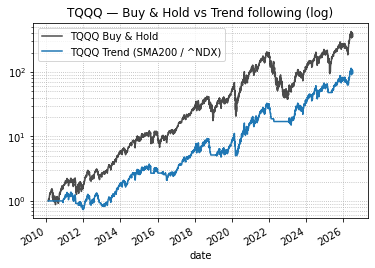

In [4]:
tqqq_idx = align(ndx, tqqq.index)              # ^NDX sur le calendrier TQQQ
tqqq_trend_eq, tqqq_pos = apply_timing(tqqq, trend_following(tqqq_idx))

stats(tqqq / tqqq.iloc[0], "TQQQ Buy & Hold")
stats(tqqq_trend_eq,       "TQQQ Trend (SMA200 on ^NDX)")
print(f"Temps en marché: {tqqq_pos.mean():.0%}")

ax = (tqqq / tqqq.iloc[0]).plot(logy=True, label="TQQQ Buy & Hold", color="black", alpha=.7)
tqqq_trend_eq.plot(ax=ax, label="TQQQ Trend (SMA200 / ^NDX)")
ax.set_title("TQQQ — Buy & Hold vs Trend following (log)"); ax.legend(); ax.grid(True, which="both", ls=":");

## 5. QLD — trend following (signal sur ^NDX)

Idem pour **QLD (2×)** : signal SMA200 sur le Nasdaq-100, appliqué aux rendements de QLD.

QLD Buy & Hold                     total:   9120.4%  CAGR:25.34%  Sharpe: 0.74  maxDD: -83.1%
QLD Trend (SMA200 on ^NDX)         total:   4670.4%  CAGR:21.28%  Sharpe: 0.79  maxDD: -45.3%
Temps en marché: 77%


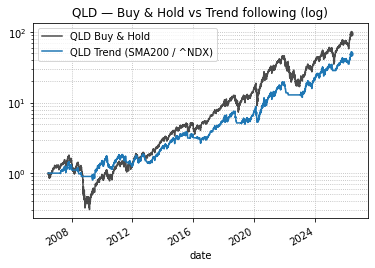

In [5]:
qld_idx = align(ndx, qld.index)
qld_trend_eq, qld_pos = apply_timing(qld, trend_following(qld_idx))

stats(qld / qld.iloc[0], "QLD Buy & Hold")
stats(qld_trend_eq,      "QLD Trend (SMA200 on ^NDX)")
print(f"Temps en marché: {qld_pos.mean():.0%}")

ax = (qld / qld.iloc[0]).plot(logy=True, label="QLD Buy & Hold", color="black", alpha=.7)
qld_trend_eq.plot(ax=ax, label="QLD Trend (SMA200 / ^NDX)")
ax.set_title("QLD — Buy & Hold vs Trend following (log)"); ax.legend(); ax.grid(True, which="both", ls=":");

## 6. Top-1 — plus grande capitalisation du S&P 500

Ici le sous-jacent *est* le basket lui-même : le signal de tendance se calcule directement
sur son équity (aucun ETF à effet de levier n'intervient).

Top-1 Buy & Hold                   total:  23659.8%  CAGR:16.17%  Sharpe: 0.66  maxDD: -77.1%
Top-1 Trend (SMA200)               total:   6400.8%  CAGR:12.12%  Sharpe: 0.64  maxDD: -42.4%
Temps en marché: 70%


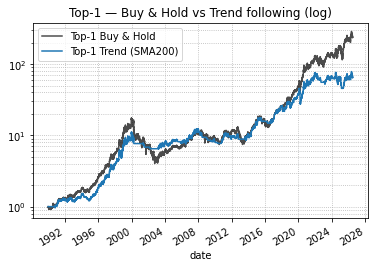

In [6]:
top1_trend_eq, top1_pos = apply_timing(top1, trend_following(top1))

stats(top1 / top1.iloc[0], "Top-1 Buy & Hold")
stats(top1_trend_eq,       "Top-1 Trend (SMA200)")
print(f"Temps en marché: {top1_pos.mean():.0%}")

ax = (top1 / top1.iloc[0]).plot(logy=True, label="Top-1 Buy & Hold", color="black", alpha=.7)
top1_trend_eq.plot(ax=ax, label="Top-1 Trend (SMA200)")
ax.set_title("Top-1 — Buy & Hold vs Trend following (log)"); ax.legend(); ax.grid(True, which="both", ls=":");

## 7. Nouveau signal : trend following **SMA + VIX**

Idée : la SMA seule génère du bruit (faux signaux quand le prix oscille autour de la moyenne).
Le **VIX** (volatilité implicite) est un filtre de régime complémentaire : les cassures de tendance
et les krachs s'accompagnent presque toujours d'une **explosion du VIX**. On l'utilise pour :

1. **Confirmer** la tendance → réduit le bruit (on n'est long que si tendance *et* volatilité maîtrisée).
2. **Doser** l'exposition → plus le VIX est bas, plus la position est grande.

On produit **deux signaux** alignés jour par jour :

- **Signal binaire** `sig_bin ∈ {0, 1}` : long si `prix > SMA(n)` **ET** `VIX < VIX_HIGH`.
- **Signal continu** `sig_cont ∈ {0.0, 0.1, …, 1.0}` (incréments de 0,1, recalculé chaque jour) :

  ```
  gate      = 1 si prix > SMA(n) sinon 0            # porte de tendance
  vix_scale = clip( (VIX_HIGH - VIX) / (VIX_HIGH - VIX_LOW), 0, 1 )
  sig_cont  = round( gate * vix_scale * 10 ) / 10   # arrondi au 0,1
  ```

  Le VIX bougeant tous les jours, `sig_cont` peut changer quotidiennement → parfait pour piloter
  la **taille de position**. `sig_cont` est directement réutilisable comme position fractionnaire.

Paramètres : `SMA=200`, `VIX_LOW=16` (plein risque en dessous), `VIX_HIGH=32` (hors marché au-dessus).

In [7]:
VIX_LOW, VIX_HIGH = 16.0, 32.0

def sma_vix_signal(price, vix_series, window=SMA_TREND, vix_low=VIX_LOW, vix_high=VIX_HIGH):
    """Retourne un DataFrame avec:
       - sig_bin  : signal binaire {0,1}
       - sig_cont : signal continu {0.0,0.1,...,1.0} (sizing), recalculé chaque jour.
    `price` et `vix_series` sont calculés sur le sous-jacent (indice), pas l'ETF."""
    v = vix_series.reindex(price.index, method="ffill")
    sma = price.rolling(window).mean()
    gate = (price > sma).astype(float)                       # porte de tendance

    sig_bin = (gate.astype(bool) & (v < vix_high)).astype(float)

    vix_scale = ((vix_high - v) / (vix_high - vix_low)).clip(0.0, 1.0)
    sig_cont = np.round(gate * vix_scale * 10) / 10.0        # incréments de 0,1

    return pd.DataFrame({"sig_bin": sig_bin, "sig_cont": sig_cont,
                         "vix": v, "sma": sma, "price": price})

# Aperçu sur le Nasdaq-100
sig_ndx = sma_vix_signal(ndx, vix)
sig_ndx[["price", "sma", "vix", "sig_bin", "sig_cont"]].tail(8)

,price,sma,vix,sig_bin,sig_cont
date,,,,,
2026-06-23,"29,347.2695","25,895.0914",19.4900,1.0000,0.8000
2026-06-24,"29,220.0605","25,922.9295",18.6300,1.0000,0.8000
2026-06-25,"29,440.3203","25,951.3196",18.8900,1.0000,0.8000
2026-06-26,"29,118.2402","25,977.7118",18.4100,1.0000,0.8000
2026-06-29,"29,774.7500","26,007.3392",17.6500,1.0000,0.9000
2026-06-30,"30,276.3496","26,038.7582",16.4500,1.0000,1.0000
2026-07-01,"29,809.1309","26,067.3429",16.5900,1.0000,1.0000
2026-07-02,"29,329.2109","26,092.5200",16.1500,1.0000,1.0000


### Distribution du signal continu

Vérifie qu'on obtient bien des paliers de 0,1 qui varient dans le temps.

Répartition des niveaux de sizing (part des jours):
sig_cont
0.0000   0.2690
0.1000   0.0080
0.2000   0.0120
0.3000   0.0130
0.4000   0.0220
0.5000   0.0290
0.6000   0.0410
0.7000   0.0550
0.8000   0.0680
0.9000   0.0810
1.0000   0.4020
Name: count, dtype: float64


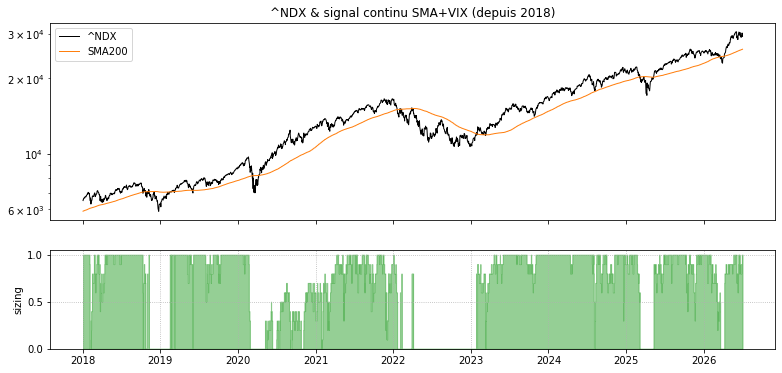

In [8]:
counts = sig_ndx["sig_cont"].value_counts().sort_index()
print("Répartition des niveaux de sizing (part des jours):")
print((counts / counts.sum()).round(3))

fig, (a1, a2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True, height_ratios=[2, 1])
recent = sig_ndx.loc["2018":]
a1.plot(recent.index, recent["price"], label="^NDX", color="black", lw=1)
a1.plot(recent.index, recent["sma"], label=f"SMA{SMA_TREND}", color="tab:orange", lw=1)
a1.set_yscale("log"); a1.legend(); a1.set_title("^NDX & signal continu SMA+VIX (depuis 2018)")
a2.fill_between(recent.index, recent["sig_cont"], step="pre", alpha=.5, color="tab:green")
a2.set_ylabel("sizing"); a2.set_ylim(0, 1.05); a2.grid(True, ls=":");

## 8. Backtest du nouveau signal SMA + VIX

Signal calculé sur le **sous-jacent** (^NDX pour QLD/TQQQ ; l'équity Top-1 pour Top-1, avec son propre
VIX de marché) puis appliqué aux rendements de l'actif tradé. On compare, pour chaque actif :
**Buy & Hold**, **Trend SMA200 seul**, **SMA+VIX binaire**, **SMA+VIX continu (sizing)**.

In [9]:
def backtest_sma_vix(asset_price, signal_underlying, vix_series, label):
    """asset_price      : ce qu'on trade (ETF ou basket)
       signal_underlying: série sur laquelle on calcule le signal (indice)
       vix_series       : VIX (filtre de régime)"""
    su = align(signal_underlying, asset_price.index)
    sig = sma_vix_signal(su, vix_series)

    bh = asset_price / asset_price.iloc[0]
    trend_eq, _ = apply_timing(asset_price, trend_following(su))
    bin_eq,  _  = apply_timing(asset_price, sig["sig_bin"])
    cont_eq, cont_pos = apply_timing(asset_price, sig["sig_cont"])

    print(f"\n=== {label} ===")
    stats(bh,       f"{label} Buy & Hold")
    stats(trend_eq, f"{label} Trend SMA200")
    stats(bin_eq,   f"{label} SMA+VIX binaire")
    stats(cont_eq,  f"{label} SMA+VIX continu")
    print(f"Exposition moyenne (continu): {cont_pos.mean():.0%}")

    return dict(bh=bh, trend=trend_eq, binary=bin_eq, cont=cont_eq)

res_tqqq = backtest_sma_vix(tqqq, ndx, vix, "TQQQ")
res_qld  = backtest_sma_vix(qld,  ndx, vix, "QLD")
res_top1 = backtest_sma_vix(top1, top1, vix, "Top-1")


=== TQQQ ===
TQQQ Buy & Hold                    total:  35497.2%  CAGR:43.12%  Sharpe: 0.90  maxDD: -81.7%
TQQQ Trend SMA200                  total:   9490.1%  CAGR:32.11%  Sharpe: 0.85  maxDD: -54.8%
TQQQ SMA+VIX binaire               total:   5766.2%  CAGR:28.21%  Sharpe: 0.79  maxDD: -54.2%
TQQQ SMA+VIX continu               total:   2751.4%  CAGR:22.69%  Sharpe: 0.75  maxDD: -48.2%
Exposition moyenne (continu): 70%

=== QLD ===
QLD Buy & Hold                     total:   9120.4%  CAGR:25.34%  Sharpe: 0.74  maxDD: -83.1%
QLD Trend SMA200                   total:   4670.4%  CAGR:21.28%  Sharpe: 0.79  maxDD: -45.3%
QLD SMA+VIX binaire                total:   3171.9%  CAGR:19.02%  Sharpe: 0.75  maxDD: -47.5%
QLD SMA+VIX continu                total:   1395.1%  CAGR:14.46%  Sharpe: 0.71  maxDD: -35.3%
Exposition moyenne (continu): 64%

=== Top-1 ===
Top-1 Buy & Hold                   total:  23659.8%  CAGR:16.17%  Sharpe: 0.66  maxDD: -77.1%
Top-1 Trend SMA200                 total:   

### Comparaison graphique (TQQQ)

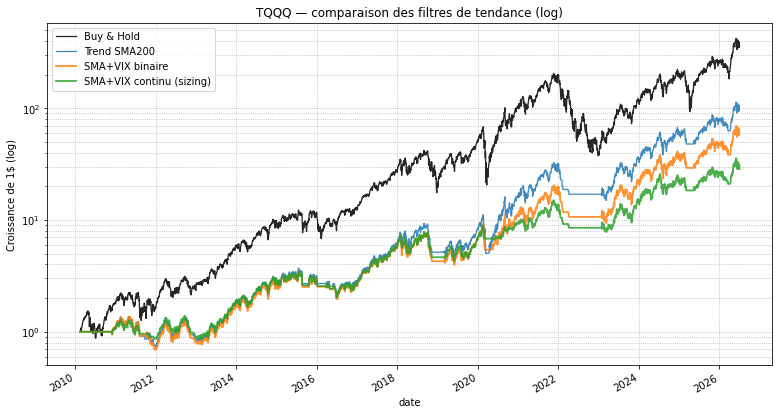

In [10]:
fig, ax = plt.subplots(figsize=(13, 7))
for k, lbl, c in [("bh", "Buy & Hold", "black"),
                  ("trend", "Trend SMA200", "tab:blue"),
                  ("binary", "SMA+VIX binaire", "tab:orange"),
                  ("cont", "SMA+VIX continu (sizing)", "tab:green")]:
    res_tqqq[k].plot(ax=ax, label=lbl, color=c, alpha=.85,
                     lw=1.8 if k in ("cont", "binary") else 1.3)
ax.set_yscale("log"); ax.set_title("TQQQ — comparaison des filtres de tendance (log)")
ax.set_ylabel("Croissance de 1$ (log)"); ax.legend(loc="upper left")
ax.grid(True, which="both", ls=":");

## 9. Piste 1 — brancher `sig_cont` sur un moteur de portefeuille (capital + DCA)

On réutilise directement le signal **continu** comme taille de position dans un moteur qui reproduit
la page de backtest interactive : **capital initial**, **DCA mensuel**, **frais par ordre** (≈ Interactive
Brokers), signal décalé d'1 jour. La position fractionnaire `sig_cont` pilote l'exposition ;
la partie non investie reste en cash (rendement 0).

TQQQ Buy & Hold                 valeur finale: $   8,793,289  investi: $ 108,500  gain: $   8,684,789  frais: $     54
TQQQ SMA+VIX continu (sizing)   valeur finale: $   1,211,387  investi: $ 108,500  gain: $   1,102,887  frais: $ 28,476


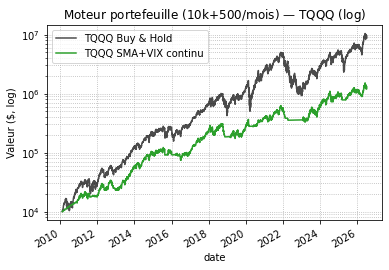

In [11]:
def simulate_portfolio(prices, pos, capital=10000, monthly=500, fee=0.0005):
    """Réplique le moteur DCA de la page web. `pos` = position brute (0..1),
    décalée d'1 jour en interne. Retourne (valeur, investi, frais)."""
    prices = prices / prices.iloc[0]
    p  = pos.reindex(prices.index).fillna(0.0).values
    px = prices.values
    dts = prices.index
    V = capital - fee * capital * p[0]
    invested, fees = capital, fee * capital * p[0]
    vals = [V]
    for i in range(1, len(px)):
        use = p[i - 1]                                   # signal décalé (no look-ahead)
        V *= (1 + use * (px[i] / px[i - 1] - 1))
        if i >= 2:                                        # frais sur variation d'expo
            dpos = abs(p[i - 1] - p[i - 2])
            if dpos > 0:
                c = fee * dpos * V; V -= c; fees += c
        if dts[i].strftime("%Y-%m") != dts[i - 1].strftime("%Y-%m"):  # DCA mensuel
            V += monthly; invested += monthly
            c = fee * monthly * use; V -= c; fees += c
        vals.append(V)
    return pd.Series(vals, index=dts), invested, fees

# TQQQ : sig_cont (VIX) vs buy & hold, avec 10 000$ + 500$/mois
sig_tqqq = sma_vix_signal(align(ndx, tqqq.index), vix)["sig_cont"]
one = pd.Series(1.0, index=tqqq.index)

for label, pos in [("Buy & Hold", one), ("SMA+VIX continu (sizing)", sig_tqqq)]:
    val, inv, fees = simulate_portfolio(tqqq, pos)
    gain = val.iloc[-1] - inv
    print(f"TQQQ {label:26s} valeur finale: ${val.iloc[-1]:>12,.0f}  "
          f"investi: ${inv:>8,.0f}  gain: ${gain:>12,.0f}  frais: ${fees:>7,.0f}")

val_bh, _, _   = simulate_portfolio(tqqq, one)
val_cont, _, _ = simulate_portfolio(tqqq, sig_tqqq)
ax = val_bh.plot(logy=True, label="TQQQ Buy & Hold", color="black", alpha=.7)
val_cont.plot(ax=ax, label="TQQQ SMA+VIX continu", color="tab:green")
ax.set_title("Moteur portefeuille (10k$ + 500$/mois) — TQQQ (log)")
ax.set_ylabel("Valeur ($, log)"); ax.legend(); ax.grid(True, which="both", ls=":");

## 10. Piste 2 — exploration des paramètres

Signal généralisé avec quatre leviers pour réduire le bruit :

- **`window`** : fenêtre de la SMA.
- **`vix_low` / `vix_high`** : bornes du dosage VIX.
- **`slope_days`** : n'être long que si la **SMA monte** (`SMA > SMA décalée de slope_days`).
- **`vix_ma`** : n'être long que si le **VIX est sous sa propre moyenne** (VIX qui se calme).

On balaie une grille sur TQQQ (signal sur ^NDX) et on classe par Sharpe.

In [12]:
def build_signal(price, vix_series, window=200, vix_low=16, vix_high=32,
                 slope_days=0, vix_ma=0):
    """Signal SMA+VIX généralisé -> DataFrame(sig_bin, sig_cont)."""
    v = vix_series.reindex(price.index, method="ffill")
    sma = price.rolling(window).mean()
    gate = (price > sma).astype(float)
    if slope_days > 0:
        gate = gate * (sma > sma.shift(slope_days)).astype(float)      # SMA en hausse
    if vix_ma > 0:
        gate = gate * (v < v.rolling(vix_ma).mean()).astype(float)     # VIX < sa MA
    sig_bin = (gate.astype(bool) & (v < vix_high)).astype(float)
    vix_scale = ((vix_high - v) / (vix_high - vix_low)).clip(0.0, 1.0)
    sig_cont = np.round(gate * vix_scale * 10) / 10.0
    return pd.DataFrame({"sig_bin": sig_bin, "sig_cont": sig_cont})

def metrics(equity):
    total = equity.iloc[-1] / equity.iloc[0] - 1
    years = (equity.index[-1] - equity.index[0]).days / 365.25
    cagr  = (equity.iloc[-1] / equity.iloc[0]) ** (1 / years) - 1
    r = equity.pct_change().dropna()
    sharpe = (r.mean() / r.std()) * np.sqrt(AF) if r.std() > 0 else float("nan")
    mdd = (equity / equity.cummax() - 1).min()
    return dict(total=total, CAGR=cagr, Sharpe=sharpe, maxDD=mdd)

ndx_on_tqqq = align(ndx, tqqq.index)
rows = []
for window in (100, 150, 200):
    for vix_high in (28, 32, 40):
        for slope_days in (0, 20):
            for vix_ma in (0, 50):
                sig = build_signal(ndx_on_tqqq, vix, window=window,
                                   vix_high=vix_high, slope_days=slope_days, vix_ma=vix_ma)["sig_cont"]
                eq, _ = apply_timing(tqqq, sig)
                m = metrics(eq)
                rows.append(dict(window=window, vix_high=vix_high, slope=slope_days,
                                 vix_ma=vix_ma, expo=sig.mean(), **m))

sweep = pd.DataFrame(rows).sort_values("Sharpe", ascending=False).reset_index(drop=True)
print("Top 8 configs (TQQQ, triées par Sharpe):")
print(sweep.head(8).to_string(index=False,
      formatters={"total": "{:.0%}".format, "CAGR": "{:.1%}".format,
                  "Sharpe": "{:.2f}".format, "maxDD": "{:.1%}".format, "expo": "{:.0%}".format}))
print("\nMeilleur maxDD (le moins négatif):")
print(sweep.sort_values("maxDD", ascending=False).head(5).to_string(index=False,
      formatters={"total": "{:.0%}".format, "CAGR": "{:.1%}".format,
                  "Sharpe": "{:.2f}".format, "maxDD": "{:.1%}".format, "expo": "{:.0%}".format}))

Top 8 configs (TQQQ, triées par Sharpe):
 window  vix_high  slope  vix_ma expo total  CAGR Sharpe  maxDD
    150        40      0      50  49% 3252% 23.9%   0.92 -30.8%
    150        32      0      50  48% 2425% 21.8%   0.88 -30.6%
    150        40      0       0  73% 6211% 28.8%   0.87 -45.6%
    150        28      0      50  47% 1952% 20.2%   0.85 -30.6%
    200        40      0      50  48% 2136% 20.9%   0.84 -43.3%
    200        40     20      50  46% 1870% 19.9%   0.82 -40.0%
    150        32      0       0  70% 3882% 25.2%   0.81 -43.9%
    200        32      0      50  47% 1701% 19.3%   0.81 -40.5%

Meilleur maxDD (le moins négatif):
 window  vix_high  slope  vix_ma expo total  CAGR Sharpe  maxDD
    150        28      0      50  47% 1952% 20.2%   0.85 -30.6%
    150        32      0      50  48% 2425% 21.8%   0.88 -30.6%
    150        40      0      50  49% 3252% 23.9%   0.92 -30.8%
    200        28     20      50  44% 1238% 17.1%   0.76 -36.6%
    200        32     20   

## 11. Piste 3 — portefeuille combiné TQQQ / QLD / Top-1 piloté par `sig_cont`

Chaque actif reçoit **son propre** `sig_cont` (calculé sur son sous-jacent : ^NDX pour QLD/TQQQ,
l'équity Top-1 pour Top-1). On équipondère les trois briques (1/3 chacune) et chaque brique est
**dimensionnée par son signal continu**. Le rendement quotidien du portefeuille est
`(1/3) · Σ sig_cont_i · rendement_i` ; la part non allouée reste en cash.
On restreint à la période commune (début de TQQQ).

Période commune: 2010-02-11 -> 2026-07-02  (4122 jours)
Combo 1/3-1/3-1/3 Buy & Hold       total:  13496.6%  CAGR:34.96%  Sharpe: 0.92  maxDD: -62.2%
Combo piloté par sig_cont          total:   1415.8%  CAGR:18.05%  Sharpe: 0.80  maxDD: -34.5%


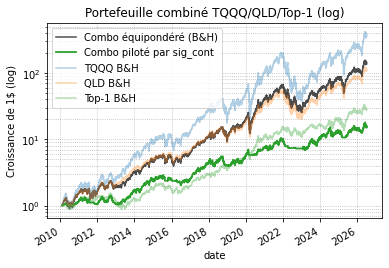

In [13]:
common = tqqq.index.intersection(qld.index).intersection(top1.index)
print(f"Période commune: {common.min().date()} -> {common.max().date()}  ({len(common)} jours)")

assets = {
    "TQQQ": (tqqq, ndx),
    "QLD":  (qld,  ndx),
    "Top-1": (top1, top1),
}
W = 1.0 / len(assets)

def asset_leg(price, underlying, dates):
    """(rendement quotidien, position sig_cont décalée) sur `dates`."""
    sig = sma_vix_signal(align(underlying, price.index), vix)["sig_cont"]
    ret = price.pct_change().reindex(dates).fillna(0.0)
    pos = sig.reindex(dates).shift(1).fillna(0.0)
    return ret, pos

# Portefeuille piloté par sig_cont
port_ret = pd.Series(0.0, index=common)
bh_ret   = pd.Series(0.0, index=common)   # référence : équipondéré plein (sizing = 1)
for name, (price, und) in assets.items():
    ret, pos = asset_leg(price, und, common)
    port_ret += W * pos * ret
    bh_ret   += W * ret

port_eq = (1 + port_ret).cumprod()
bh_eq   = (1 + bh_ret).cumprod()

stats(bh_eq,   "Combo 1/3-1/3-1/3 Buy & Hold")
stats(port_eq, "Combo piloté par sig_cont")

# Chaque actif seul (buy & hold) sur la période commune, pour comparaison
ax = (bh_eq).plot(logy=True, label="Combo équipondéré (B&H)", color="black", alpha=.7)
port_eq.plot(ax=ax, label="Combo piloté par sig_cont", color="tab:green", lw=1.8)
for name, (price, _) in assets.items():
    (price.reindex(common) / price.reindex(common).iloc[0]).plot(ax=ax, alpha=.35, label=f"{name} B&H")
ax.set_title("Portefeuille combiné TQQQ/QLD/Top-1 (log)")
ax.set_ylabel("Croissance de 1$ (log)"); ax.legend(loc="upper left"); ax.grid(True, which="both", ls=":");

### Portefeuille combiné + moteur capital/DCA

On branche le portefeuille combiné (traité comme une brique tradable, sizing déjà intégré) sur le
moteur capital initial + DCA.

In [14]:
val_combo, inv_c, fees_c = simulate_portfolio(port_eq, pd.Series(1.0, index=port_eq.index))
val_ew,    inv_e, fees_e = simulate_portfolio(bh_eq,   pd.Series(1.0, index=bh_eq.index))
print(f"Combo sig_cont  valeur: ${val_combo.iloc[-1]:>12,.0f}  gain: ${val_combo.iloc[-1]-inv_c:>12,.0f}")
print(f"Combo B&H       valeur: ${val_ew.iloc[-1]:>12,.0f}  gain: ${val_ew.iloc[-1]-inv_e:>12,.0f}")
print("\nMétriques NAV (base 1):")
for lbl, eq in [("Combo B&H", bh_eq), ("Combo sig_cont", port_eq)]:
    m = metrics(eq)
    print(f"  {lbl:16s} CAGR {m['CAGR']:>6.1%}  Sharpe {m['Sharpe']:>4.2f}  maxDD {m['maxDD']:>6.1%}")

Combo sig_cont  valeur: $     706,127  gain: $     597,627
Combo B&H       valeur: $   4,133,591  gain: $   4,025,091

Métriques NAV (base 1):
  Combo B&H        CAGR  35.0%  Sharpe 0.92  maxDD -62.2%
  Combo sig_cont   CAGR  18.0%  Sharpe 0.80  maxDD -34.5%


## 12. Conclusion

- **Piste 1** : `sig_cont` se branche tel quel sur le moteur capital + DCA (position fractionnaire).
- **Piste 2** : la grille montre l'arbitrage rendement / drawdown selon `window`, `vix_high`, la pente
  de la SMA et le filtre VIX-vs-sa-moyenne ; les filtres supplémentaires réduisent le drawdown au prix
  d'une exposition (et d'un CAGR) plus faibles.
- **Piste 3** : le combo 1/3-1/3-1/3 piloté par `sig_cont` lisse la volatilité par rapport à chaque
  actif seul, tout en gardant le contrôle du drawdown via le dosage VIX.